# Task 3 - Model Comparison
Load outputs from SARIMA/LSTM/GRU and build plots + tables.

In [12]:
# Load model outputs
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Search current working output first, then attached datasets for exported CSVs.
SEARCH_ROOTS = [Path("/kaggle/working/outputs"), Path("outputs"), Path("/kaggle/input")]
SEARCH_ROOTS = [root for root in SEARCH_ROOTS if root.exists()]
print("Search roots:")
for root in SEARCH_ROOTS:
    print(" -", root.resolve())

def find_file(filename: str) -> Path | None:
    for root in SEARCH_ROOTS:
        matches = list(root.rglob(filename)) if root.is_dir() else []
        if matches:
            return matches[0]
    return None

def load_metrics(filename: str, model_name: str) -> pd.DataFrame | None:
    path = find_file(filename)
    if path is None:
        print(f"Missing metrics file for {model_name}: {filename}")
        return None
    df = pd.read_csv(path)
    df["model"] = model_name
    df["source_file"] = str(path)
    return df

metrics_frames = [
    load_metrics("metrics_sarima.csv", "SARIMA"),
    load_metrics("metrics_lstm.csv", "LSTM"),
    load_metrics("metrics_gru.csv", "GRU"),
]
metrics_frames = [frame for frame in metrics_frames if frame is not None]
if not metrics_frames:
    raise FileNotFoundError("No metrics CSV files were found in working output or attached datasets.")
metrics = pd.concat(metrics_frames, ignore_index=True)
metrics

Search roots:
 - /kaggle/input


,MAE,MAPE,RMSE,square_id,train_seconds,infer_seconds,model,source_file
0,1444.439300,99.862687,1984.473987,5161,2.183401,0.042833,SARIMA,/kaggle/input/notebooks/miraclenanenmbanaade/0...
1,242.458818,99.915345,271.392078,4159,2.451390,0.032963,SARIMA,/kaggle/input/notebooks/miraclenanenmbanaade/0...
2,452.049725,99.548116,480.319525,4556,1.768546,0.030631,SARIMA,/kaggle/input/notebooks/miraclenanenmbanaade/0...
3,40.311079,31.072757,56.022624,5161,6.602919,0.369468,LSTM,/kaggle/input/notebooks/miraclenanenmbanaade/0...
4,35.560734,41.114744,50.160082,4159,5.433203,0.338630,LSTM,/kaggle/input/notebooks/miraclenanenmbanaade/0...
5,85.199842,45.426489,111.890072,4556,5.703041,0.353678,LSTM,/kaggle/input/notebooks/miraclenanenmbanaade/0...
6,42.101068,35.345971,56.148681,5161,7.329975,0.423041,GRU,/kaggle/input/notebooks/miraclenanenmbanaade/0...
7,39.022783,48.852736,51.631520,4159,5.662011,0.347722,GRU,/kaggle/input/notebooks/miraclenanenmbanaade/0...
8,84.732071,44.873277,111.808587,4556,5.769323,0.342067,GRU,/kaggle/input/notebooks/miraclenanenmbanaade/0...


In [13]:
# Metrics tables by square
metrics_table = metrics.pivot_table(index=["square_id", "model"], values=["MAE", "MAPE", "RMSE"]).reset_index()
metrics_table

,square_id,model,MAE,MAPE,RMSE
0,4159,GRU,39.022783,48.852736,51.631520
1,4159,LSTM,35.560734,41.114744,50.160082
2,4159,SARIMA,242.458818,99.915345,271.392078
3,4556,GRU,84.732071,44.873277,111.808587
4,4556,LSTM,85.199842,45.426489,111.890072
5,4556,SARIMA,452.049725,99.548116,480.319525
6,5161,GRU,42.101068,35.345971,56.148681
7,5161,LSTM,40.311079,31.072757,56.022624
8,5161,SARIMA,1444.439300,99.862687,1984.473987


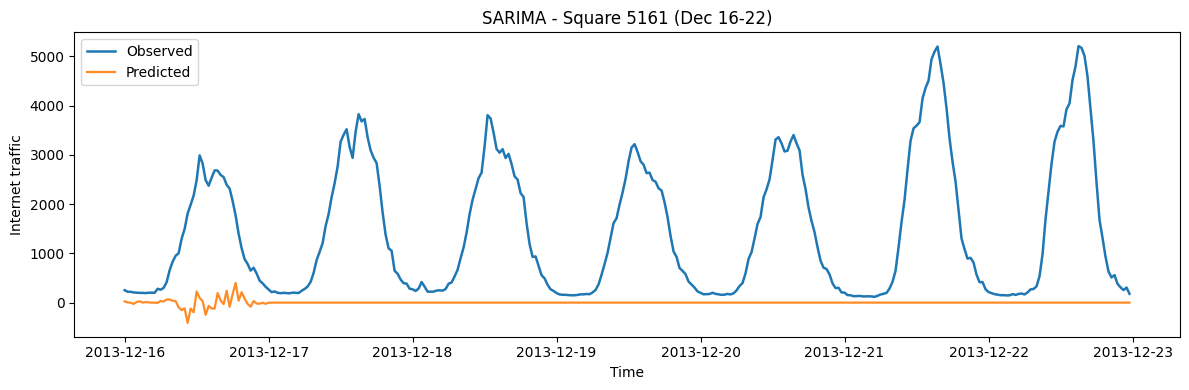

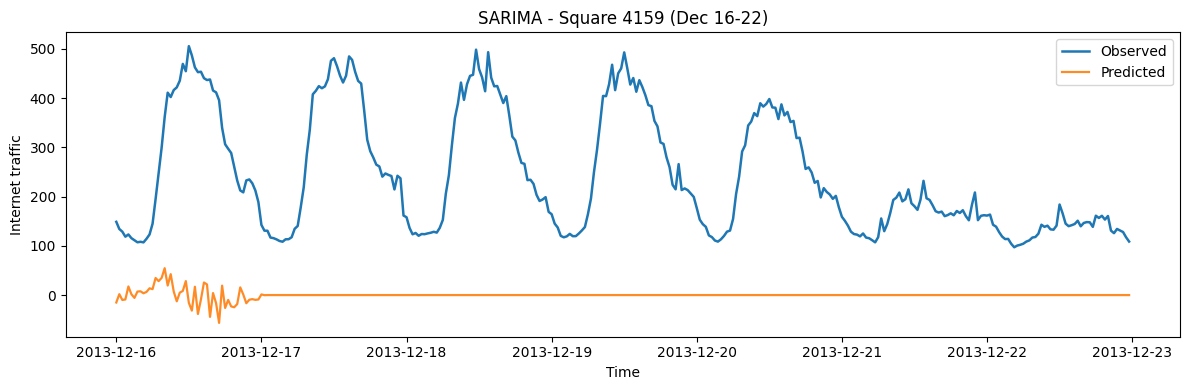

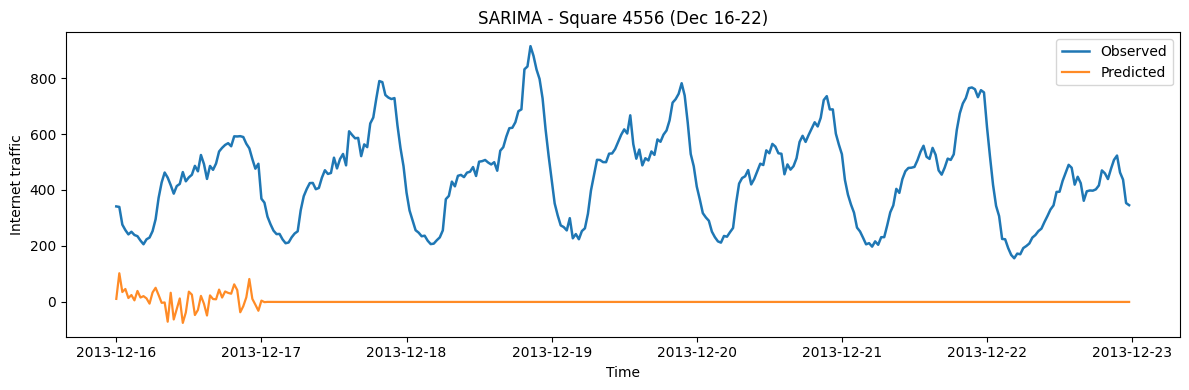

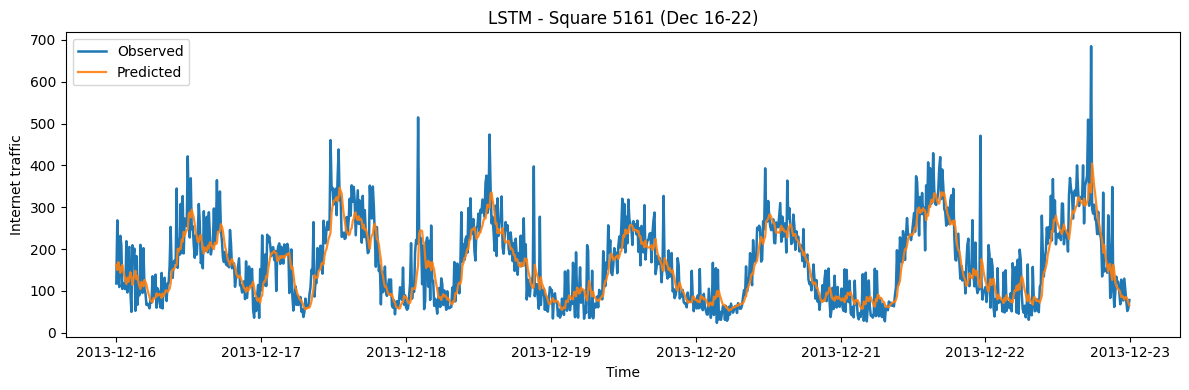

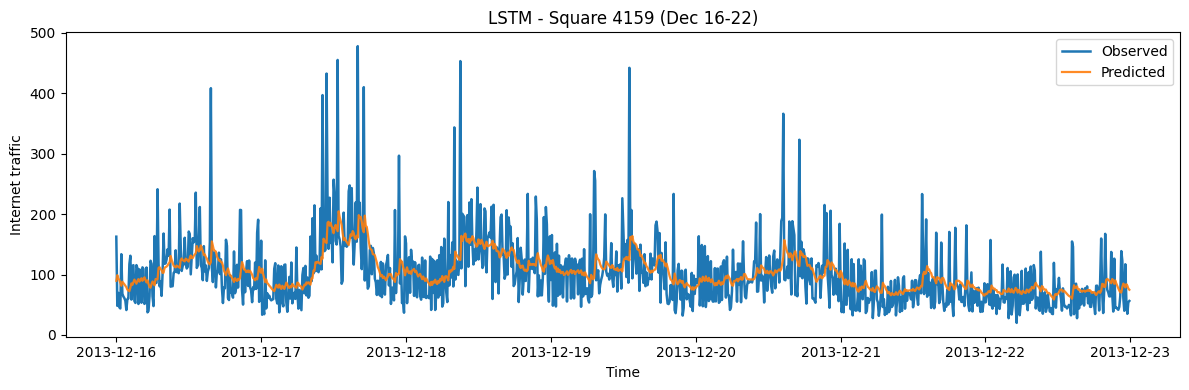

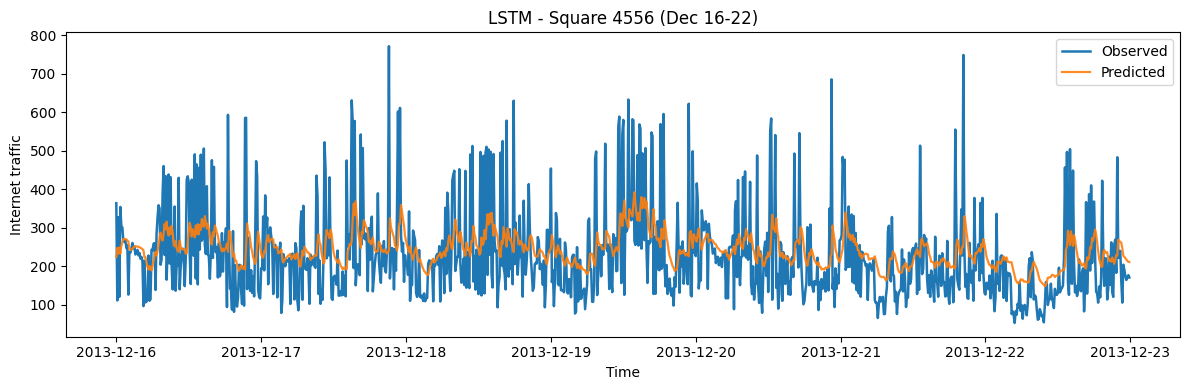

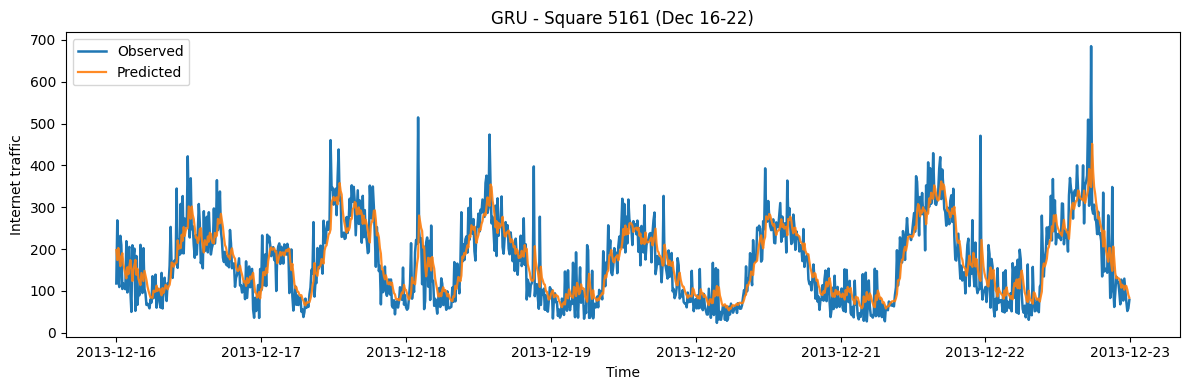

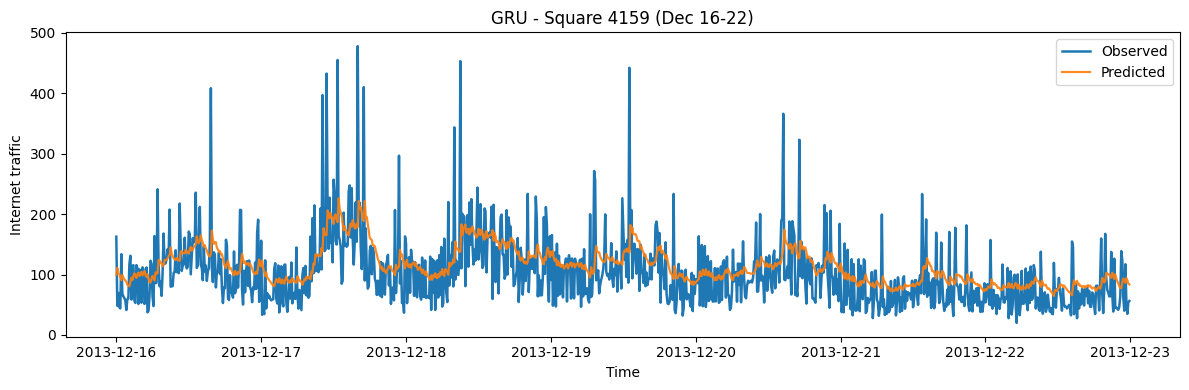

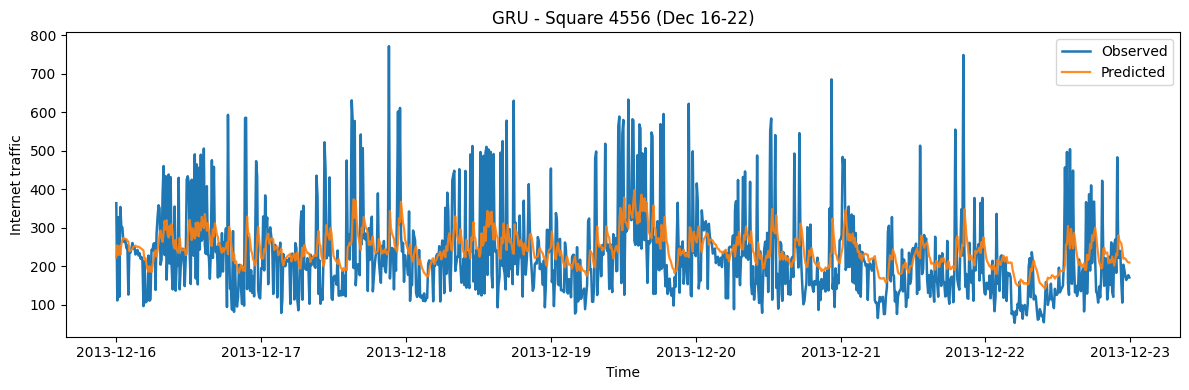

In [14]:
# Forecast overlay plots (9 total)
def plot_overlay(csv_name: str, title: str):
    csv_path = find_file(csv_name)
    if csv_path is None:
        print(f"Skipping missing forecast file: {csv_name}")
        return None
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pd.to_datetime(df["time_interval"], utc=True), df["y_true"], label="Observed", linewidth=1.8)
    ax.plot(pd.to_datetime(df["time_interval"], utc=True), df["y_pred"], label="Predicted", linewidth=1.6, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Internet traffic")
    ax.legend()
    fig.tight_layout()
    return fig

for model_name in ["sarima", "lstm", "gru"]:
    for square_id in metrics["square_id"].unique():
        csv_name = f"{model_name}_{int(square_id)}.csv"
        plot_overlay(csv_name, f"{model_name.upper()} - Square {int(square_id)} (Dec 16-22)")